In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv('weekly_driving_profiles.csv')

In [18]:
import os
import wandb # для логирования

import numpy as np
import random
from tqdm import *

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim # для оптимизаторов
from torchvision import datasets # для данных
import torchvision.transforms as transforms # для преобразований тензоров

In [19]:
class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60

In [20]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']
target_col = 'claims_count'


unique_drivers = df['driver_id'].unique()

#примерно 70% обучение 30% тест
train_drivers, test_drivers = train_test_split(unique_drivers, test_size=0.3, random_state=30)

X_train = df[df['driver_id'].isin(train_drivers)][feature_cols]
X_test = df[df['driver_id'].isin(test_drivers)][feature_cols]
y_train = df[df['driver_id'].isin(train_drivers)][target_col]
y_test = df[df['driver_id'].isin(test_drivers)][target_col]

print("Количество водителей в тренировке: ",len(train_drivers), "Количество строк: ",len(X_train))
print("Количество водителей в тесте: ",len(test_drivers), "Количество строк: ",len(X_test))


#масштабирование признаков
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)


train_data = TensorDataset(X_train_t, y_train_t)
test_data = TensorDataset(X_test_t, y_test_t)

#рекомендуют для датасета 10к-100к батчсайз 64
batch_size = 64

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)


Количество водителей в тренировке:  247 Количество строк:  8465
Количество водителей в тесте:  107 Количество строк:  4063


In [21]:
def seed_everything(seed):
    random.seed(seed) # фиксируем генератор случайных чисел
    os.environ['PYTHONHASHSEED'] = str(seed) # фиксируем заполнения хешей
    np.random.seed(seed) # фиксируем генератор случайных чисел numpy
    torch.manual_seed(seed) # фиксируем генератор случайных чисел pytorch
    torch.cuda.manual_seed(seed) # фиксируем генератор случайных чисел для GPU
    #torch.backends.cudnn.deterministic = True # выбираем только детерминированные алгоритмы (для сверток)
    #torch.backends.cudnn.benchmark = False # фиксируем алгоритм вычисления сверток
seed_everything(30)

In [22]:
class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.ReLU(),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.ReLU(),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.ReLU(),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x

In [23]:
model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель


Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [25]:
# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

optimizer = torch.optim.Adam(model.parameters(),lr = 0.001)

Первостепенно поменяли функцию потерь на Пуассоновскую, так как:

Мы предугадываем интенсивность (кол-во страховых случаев в год, то есть количество действий за фиксированный промежуток времени). Главный параметр в распределении Пуассона, как раз интенсивность! Что прекрасно накладывается на наш тест. Также в целом мат.ожидание и дисперсия в данном распределении также равны лямбда.

Распределение Пуассона имеет такой график:

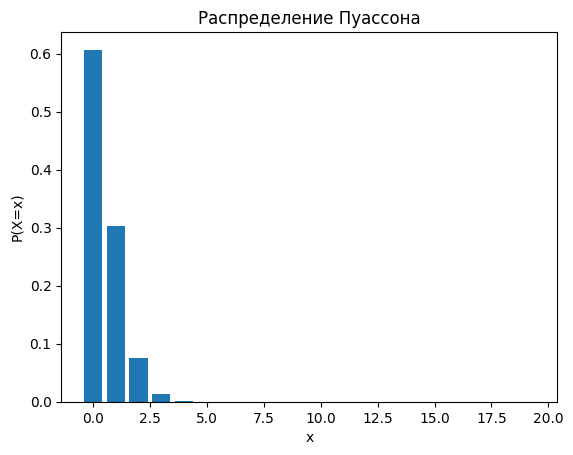

In [26]:
from scipy.stats import poisson
lam = 0.5

x = np.arange(0, 20)

pmf = poisson.pmf(x, lam)

plt.bar(x, pmf)
plt.xlabel('x')
plt.ylabel('P(X=x)')
plt.title(f'Распределение Пуассона')
plt.show()

график распределения целевой переменной:

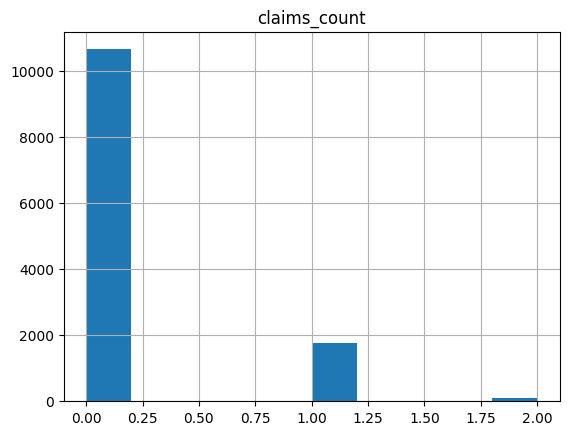

In [ ]:
df['claims_count'].hist(bins=10)
plt.title('claims_count')
plt.show()

Распределения очень близки. Пуассон будет хорошо интерпретировать нашу задачу.

Также данная функция ошибки сильнее штрафует за большие веса. Для нас это максимально важно! Ведь если мы дадим скидку тому, кто попадет на страховой случай - потеряем в деньгах. Так что лучше не рисковать

Еще один бонус - прекрасная интерпретация результатов, ведь на выходе модели мы получаем ту самую интенсивность!

In [27]:
# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0


    n_ex = len(train_loader)

    for batch_idx, (data, target) in tqdm(enumerate(train_loader), total=n_ex):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)

    tqdm.write('\nTrain set: Average loss: {:.4f}'.format(
        train_loss_sum / len(train_loader.dataset)))


In [28]:
# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    tqdm.write('Test set: Average loss: {:.4f}'.format(
       test_loss_sum / len(test_loader.dataset)))
    return test_loss_sum / len(test_loader.dataset)


In [29]:
# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи
        print('\nEpoch:', epoch)
        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))

In [30]:
main(model)


Epoch: 1


100%|██████████| 133/133 [00:00<00:00, 458.22it/s]



Train set: Average loss: 1.0385
Test set: Average loss: 0.9566

Epoch: 2


100%|██████████| 133/133 [00:00<00:00, 460.97it/s]



Train set: Average loss: 0.9105
Test set: Average loss: 0.8734

Epoch: 3


...


Train set: Average loss: 0.3617
Test set: Average loss: 0.5197

Epoch: 59


100%|██████████| 133/133 [00:01<00:00, 121.95it/s]



Train set: Average loss: 0.3593
Test set: Average loss: 0.5232

Epoch: 60


100%|██████████| 133/133 [00:00<00:00, 239.85it/s]


Train set: Average loss: 0.3584
Test set: Average loss: 0.5155
Training is ended!

BEST EPOCH:  26 with Loss:  0.48666602238524936


Сделали важное изменение - поменяли функцию потерь. Теперь будем играться со всем остальным, чтобы создать наилучшую модель!

Лучшая эпоха: BEST EPOCH:  26 with Loss:  0.48666602238524936

## Добавим Dropout

In [31]:
class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60

In [32]:
class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x

In [33]:
model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

optimizer = torch.optim.Adam(model.parameters(),lr = 0.001)

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in tqdm(enumerate(train_loader), total=n_ex):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)

    tqdm.write('\nTrain set: Average loss: {:.4f}'.format(
        train_loss_sum / len(train_loader.dataset)))

# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    tqdm.write('Test set: Average loss: {:.4f}'.format(
       test_loss_sum / len(test_loader.dataset)))
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи
        print('\nEpoch:', epoch)
        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))

Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [34]:
main(model)


Epoch: 1


100%|██████████| 133/133 [00:00<00:00, 400.42it/s]



Train set: Average loss: 0.6411
Test set: Average loss: 0.4977

Epoch: 2


100%|██████████| 133/133 [00:00<00:00, 418.86it/s]



Train set: Average loss: 0.4584
Test set: Average loss: 0.4896

Epoch: 3


...


Train set: Average loss: 0.3722
Test set: Average loss: 0.4928

Epoch: 59


100%|██████████| 133/133 [00:00<00:00, 394.60it/s]



Train set: Average loss: 0.3741
Test set: Average loss: 0.4943

Epoch: 60


100%|██████████| 133/133 [00:00<00:00, 434.66it/s]


Train set: Average loss: 0.3659
Test set: Average loss: 0.5001
Training is ended!

BEST EPOCH:  14 with Loss:  0.4788277227282084


BEST EPOCH:  14 with Loss:  0.4788277227282084- видим улучшение!

Dropout оставляем

Почему он уменьшил ошибку?

Помогает сделать нейроны независимыми друг от друга (так как 20% отключаем, им приходится работать без них). Это вынуждает нейроны не запоминать конкретные примеры, а искать общие паттерны

добавим weight_decay=1e-5 для уменьшения переобучения

In [35]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x

model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

optimizer = torch.optim.Adam(model.parameters(),lr = 0.001, weight_decay=1e-5)

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in tqdm(enumerate(train_loader), total=n_ex):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)

    tqdm.write('\nTrain set: Average loss: {:.4f}'.format(
        train_loss_sum / len(train_loader.dataset)))

# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    tqdm.write('Test set: Average loss: {:.4f}'.format(
       test_loss_sum / len(test_loader.dataset)))
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи
        print('\nEpoch:', epoch)
        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))

Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [36]:
main(model)


Epoch: 1


100%|██████████| 133/133 [00:00<00:00, 228.35it/s]



Train set: Average loss: 0.5799
Test set: Average loss: 0.4915

Epoch: 2


100%|██████████| 133/133 [00:00<00:00, 351.25it/s]



Train set: Average loss: 0.4520
Test set: Average loss: 0.4832

Epoch: 3


...


Train set: Average loss: 0.3602
Test set: Average loss: 0.5095

Epoch: 59


100%|██████████| 133/133 [00:00<00:00, 423.10it/s]



Train set: Average loss: 0.3606
Test set: Average loss: 0.5084

Epoch: 60


100%|██████████| 133/133 [00:00<00:00, 270.94it/s]



Train set: Average loss: 0.3628
Test set: Average loss: 0.5062
Training is ended!

BEST EPOCH:  14 with Loss:  0.475916059812888


здесь не видим особых изменений.

Давайте в целом поиграемся с разными оптимизаторами

https://habr.com/ru/articles/813221/#faster_optimizers - берем отсюда

## Оптимизаторы

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x


model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

optimizer = torch.optim.Adam(model.parameters(),lr = 0.001, weight_decay=1e-5)

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)


# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи

        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))

Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=8, out_features=1, bias=True)
  )
)


Momentum

In [37]:

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x

model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

optimizer = torch.optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)


# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи

        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))
main(model)

Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=8, out_features=1, bias=True)
  )
)
Training is ended!

BEST EPOCH:  37 with Loss:  0.4896679284748349


In [38]:
#Nesterov momentum

class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x

model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)


# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи

        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))
main(model)

Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=8, out_features=1, bias=True)
  )
)
Training is ended!

BEST EPOCH:  60 with Loss:  0.48400109328206703


In [39]:
#RMSProp
class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x


model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001, alpha=0.99)

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)


# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи

        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))
main(model)

Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=8, out_features=1, bias=True)
  )
)
Training is ended!

BEST EPOCH:  16 with Loss:  0.4763929787202624


In [40]:
#AdaMax
class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x


model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

optimizer = torch.optim.Adamax(model.parameters(), lr=0.001, betas=(0.9, 0.999))

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)


# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи

        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))
main(model)

Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=8, out_features=1, bias=True)
  )
)
Training is ended!

BEST EPOCH:  55 with Loss:  0.47490470974339133


In [41]:
#Nadam
class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x


model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

optimizer = torch.optim.NAdam(model.parameters(), lr=0.001, betas=(0.9, 0.999))

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)


# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи

        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))
main(model)

Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=8, out_features=1, bias=True)
  )
)
Training is ended!

BEST EPOCH:  14 with Loss:  0.4760387646148512


In [42]:
#AdamW
class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x


model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)


# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи

        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))
main(model)

Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=8, out_features=1, bias=True)
  )
)
Training is ended!

BEST EPOCH:  14 with Loss:  0.47540342541874087


In [43]:
!pip install torch_optimizer

import torch_optimizer as optim

class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x

model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

optimizer = optim.Yogi(model.parameters(), lr=0.01, betas=(0.9, 0.999), eps=1e-3, weight_decay=0)

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)


# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи

        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))
main(model)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 2.6 MB/s eta 0:00:00
Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=8, out_features=1, bias=True)
  )
)
Training is ended!

BEST EPOCH:  6 with Loss:  0.47104953619652185


In [44]:
!pip install git+https://github.com/sail-sg/Adan.git
from adan import Adan

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x


model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)


optimizer = Adan(model.parameters(), lr=0.01, betas=(0.98, 0.92, 0.99), weight_decay=0.02, eps=1e-8)

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)


# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи

        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))
main(model)

  Cloning https://github.com/sail-sg/Adan.git to /tmp/pip-req-build-5n8dqybu
  Running command git clone --filter=blob:none --quiet https://github.com/sail-sg/Adan.git /tmp/pip-req-build-5n8dqybu
  Resolved https://github.com/sail-sg/Adan.git to commit 2c65beaf400775753b155da4082c3819fea689b9
  Preparing metadata (setup.py) ... done
  Created wheel for adan: filename=adan-0.0.2-py3-none-any.whl size=9030 sha256=df9e6cd726f27392eb741d4d2c1d989f0c37bafcdda30017ecd4181a070761ec
  Stored in directory: /tmp/pip-ephem-wheel-cache-eejyevkl/wheels/96/89/6a/e094ca5bcde1cc3aac704da26c4f8039783a4a9cf13ff2b2de
Successfully built adan
Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=

Лучший оптимизатор:
Yogi  - BEST EPOCH:  6 with Loss:  0.47104953619652185

Его и оставим



## Параметры Yogi

Сделаем разные запуски с learning_rates = [0.1, 0.05, 0.01, 0.005, 0.001]

In [51]:
import torch_optimizer as optim

class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x

model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

#learning_rates = [0.1, 0.05, 0.01, 0.005, 0.001]
optimizer = optim.Yogi(model.parameters(), lr=0.001, betas=(0.9, 0.999), eps=1e-3, weight_decay=0)

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)


# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи

        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))
main(model)

Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=8, out_features=1, bias=True)
  )
)
Training is ended!

BEST EPOCH:  21 with Loss:  0.4758094815734922


при lr = 0.005 BEST EPOCH:  6 with Loss:  0.4702626008456955 - лучший вариант

пройдемся по стабилизатору eps_values = [1e-8, 1e-6, 1e-4, 1e-3, 1e-2]

In [55]:
import torch_optimizer as optim

class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x

model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

#пройдемся по стабилизатору eps_values = [1e-8, 1e-6, 1e-4, 1e-3, 1e-2]
optimizer = optim.Yogi(model.parameters(), lr=0.005, betas=(0.9, 0.999), eps=1e-3, weight_decay=0)

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)


# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи

        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))
main(model)

Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=8, out_features=1, bias=True)
  )
)
Training is ended!

BEST EPOCH:  6 with Loss:  0.47026260084569554


оставляем изначальный

моменты betas_options = [(0.9, 0.999), (0.9, 0.99), (0.95, 0.999), (0.85, 0.995)]

In [59]:
import torch_optimizer as optim

class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x

model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

#моменты betas_options = [(0.9, 0.999), (0.9, 0.99), (0.95, 0.999), (0.85, 0.995)]
optimizer = optim.Yogi(model.parameters(), lr=0.005, betas=(0.9, 0.999), eps=1e-3, weight_decay=0)

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)


# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи

        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))
main(model)

Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=8, out_features=1, bias=True)
  )
)
Training is ended!

BEST EPOCH:  6 with Loss:  0.47026260084569554


моменты тоже не меняем)

## Резуляризации

Теперь пройдемся по регуляризациям

Начнем с простых: L1/L2 регуляризация

L2 уже есть в оптимизаторе optimizer = weight_decay=0.02


In [62]:
import torch_optimizer as optim

class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x

model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

#weight_decays = [0, 1e-5, 1e-4, 1e-3, 0.01]
optimizer = optim.Yogi(model.parameters(), lr=0.005, betas=(0.9, 0.999), eps=1e-3, weight_decay=1e-5)

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)


# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи

        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))
main(model)

Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=8, out_features=1, bias=True)
  )
)
Training is ended!

BEST EPOCH:  6 with Loss:  0.4735700246400502


 weight_decays =  1e-5
 BEST EPOCH:  6 with Loss:  0.46917934100336844 - улучшение есть!

Теперь попробуем Батч-нормализацию

In [63]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19

        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.BatchNorm1d(hidden_1),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.BatchNorm1d(hidden_2),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.BatchNorm1d(hidden_3),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x

model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

optimizer = optim.Yogi(model.parameters(), lr=0.005, betas=(0.9, 0.999), eps=1e-3, weight_decay=1e-5)

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)



# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики

    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи
        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))
main(model)

Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=16, out_features=8, bias=True)
    (9): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=8, out_features=1, bias=True)
  )
)
Training is ended!

BEST EPOCH:  12 with Loss:  0.4725517766275577


не улучшилось, так что не оставляем

## Активации

И теперь мы дошли до функции активации

In [64]:
#Sigmoid
import torch_optimizer as optim

class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.Sigmoid(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.Sigmoid(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.Sigmoid(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x

model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

#weight_decays = [0, 1e-5, 1e-4, 1e-3, 0.01]
optimizer = optim.Yogi(model.parameters(), lr=0.005, betas=(0.9, 0.999), eps=1e-3, weight_decay=1e-5)

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)


# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи

        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))
main(model)

Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): Sigmoid()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): Sigmoid()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): Sigmoid()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=8, out_features=1, bias=True)
  )
)
Training is ended!

BEST EPOCH:  55 with Loss:  0.47609662429440824


чуть хуже

In [68]:
#Tanh
import torch_optimizer as optim

class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.Tanh(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.Tanh(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.Tanh(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x

model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

#weight_decays = [0, 1e-5, 1e-4, 1e-3, 0.01]
optimizer = optim.Yogi(model.parameters(), lr=0.005, betas=(0.9, 0.999), eps=1e-3, weight_decay=1e-5)

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)


# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи

        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))
main(model)

Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): Tanh()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): Tanh()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): Tanh()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=8, out_features=1, bias=True)
  )
)
Training is ended!

BEST EPOCH:  3 with Loss:  0.4857691823482631


чуть хуэе

In [65]:
#ELU
import torch_optimizer as optim

class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.ELU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.ELU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.ELU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x

model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

#weight_decays = [0, 1e-5, 1e-4, 1e-3, 0.01]
optimizer = optim.Yogi(model.parameters(), lr=0.005, betas=(0.9, 0.999), eps=1e-3, weight_decay=1e-5)

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)


# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи

        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))
main(model)

Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): ELU(alpha=1.0)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ELU(alpha=1.0)
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ELU(alpha=1.0)
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=8, out_features=1, bias=True)
  )
)
Training is ended!

BEST EPOCH:  16 with Loss:  0.47303047995540326


тоже неплохо

In [66]:
#GELU
import torch_optimizer as optim

class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.GELU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.GELU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.GELU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x

model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

#weight_decays = [0, 1e-5, 1e-4, 1e-3, 0.01]
optimizer = optim.Yogi(model.parameters(), lr=0.005, betas=(0.9, 0.999), eps=1e-3, weight_decay=1e-5)

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)


# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи

        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))
main(model)

Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=8, out_features=1, bias=True)
  )
)
Training is ended!

BEST EPOCH:  6 with Loss:  0.4745277174435136


In [67]:
#LeakyReLU
import torch_optimizer as optim

class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.LeakyReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.LeakyReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.LeakyReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x

model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

#weight_decays = [0, 1e-5, 1e-4, 1e-3, 0.01]
optimizer = optim.Yogi(model.parameters(), lr=0.005, betas=(0.9, 0.999), eps=1e-3, weight_decay=1e-5)

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)


# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи

        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))
main(model)

Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): LeakyReLU(negative_slope=0.01)
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=8, out_features=1, bias=True)
  )
)
Training is ended!

BEST EPOCH:  6 with Loss:  0.4719071964999886


очень неплохо!

In [69]:
#Sigmoid
import torch_optimizer as optim

class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x

model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

#weight_decays = [0, 1e-5, 1e-4, 1e-3, 0.01]
optimizer = optim.Yogi(model.parameters(), lr=0.005, betas=(0.9, 0.999), eps=1e-3, weight_decay=1e-5)

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)


# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи

        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))
main(model)

Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=8, out_features=1, bias=True)
  )
)
Training is ended!

BEST EPOCH:  6 with Loss:  0.46917934100336844


Лучше всего себя показала активация RELU

---



BEST EPOCH:  6 with Loss:  0.46917934100336844

## Количество слоев

In [71]:

import torch_optimizer as optim

class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8, 4]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        hidden_4 = CFG.hidden_dims[3]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, hidden_4),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_4, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x

model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

#weight_decays = [0, 1e-5, 1e-4, 1e-3, 0.01]
optimizer = optim.Yogi(model.parameters(), lr=0.005, betas=(0.9, 0.999), eps=1e-3, weight_decay=1e-5)

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)


# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи

        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))
main(model)

Regression(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=8, out_features=4, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=4, out_features=1, bias=True)
  )
)
Training is ended!

BEST EPOCH:  10 with Loss:  0.4678306481190101


Улучшение чуть чуть есть!

## ИТОГ

In [ ]:

import torch_optimizer as optim

class CFG:

# Задаем параметры нашего эксперимента
  feature_cols = ['engine_capacity', 'road_quality_moderate', 'slope_flat',
                'motorway', 'rural', 'more_than_one_lane', 'congested',
                'speed_limit_mean', 'weather_temperature_mean', 'total_distance',
                'sum_roundabout', 'sum_traffic_signal', 'sum_stop_sign',
                'sum_yield_sign', 'sum_pedestrian_crossing_sign',
                'sum_animal_crossing_sign', 'speeding_serious',
                'harsh_acceleration', 'harsh_braking']

  input_dim = len(feature_cols)
  hidden_dims = [32, 16, 8, 4]
  dropout_rate = 0.2
  learning_rate = 0.001
  num_epochs = 60


class Regression(nn.Module): # наследуемся от класса nn.Module
    def __init__(self):
        super(Regression,self).__init__()
        # организуем 3 скрытых слоя
        hidden_1 =  CFG.hidden_dims[0]
        hidden_2 = CFG.hidden_dims[1]
        hidden_3 = CFG.hidden_dims[2]
        hidden_4 = CFG.hidden_dims[3]
        #
        input_dim = 19
        self.net = torch.nn.Sequential(
                      torch.nn.Linear(input_dim, hidden_1),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_1, hidden_2),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_2, hidden_3),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_3, hidden_4),
                      torch.nn.ReLU(),
                      torch.nn.Dropout(CFG.dropout_rate),
                      torch.nn.Linear(hidden_4, 1),
                    )

    def forward(self,x):
        x = torch.exp(self.net(x))
        return x

model = Regression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # переводим модель на GPU, не получилось, поэтому CPU
print(model) # посмотрим на нашу модель

# функция потерь
criterion =  nn.PoissonNLLLoss(log_input=False)

#weight_decays = [0, 1e-5, 1e-4, 1e-3, 0.01]
optimizer = optim.Yogi(model.parameters(), lr=0.005, betas=(0.9, 0.999), eps=1e-3, weight_decay=1e-5)

# функция обучения модели
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # обязательно переводим в режим обучения
    train_loss_sum = 0

    n_ex = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # переводим картинки и таргеты на GPU
        # обнуляем градиенты!
        optimizer.zero_grad()
        # прямой проход
        output = model(data)

        train_loss = criterion(output, target) # считаем значение функции потерь
        # обратный проход
        train_loss.backward()
        # делаем градиентный шаг оптимизатором
        optimizer.step()
        # считаем метрики и лосс
        train_loss_sum += train_loss.item() * data.size(0)


# функция тестирования
def test(model, device, test_loader, criterion):
    model.eval() # переводем модель в режим инференса
    test_loss_sum = 0

    all_predictions = []
    all_targets = []

    # показываем, что обученич нет и градиенты не обновляются
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = criterion(output, target) # считаем значение функции потерь
            test_loss_sum += test_loss.item() * data.size(0)

            predictions = output.cpu().numpy().flatten()
            targets = target.cpu().numpy().flatten()

            all_predictions.extend(predictions.tolist())
            all_targets.extend(targets.tolist())


            # считаем метрики
    return test_loss_sum / len(test_loader.dataset)

# основная функция для экспериментов
def main(model):

    seed_everything(30)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выделили устройство
    model = model.to(device)

    losses = []
    for epoch in range(1, CFG.num_epochs + 1): # цикл на эпохи

        train(model, device, train_loader, optimizer, criterion, epoch)
        losses.append(test(model, device, test_loader, criterion))
    print('Training is ended!')
    best_epoch = np.argmin(losses)+1
    print()
    print('BEST EPOCH: ', best_epoch, 'with Loss: ',min(losses))
main(model)